## Spark Session Initialization

In [116]:
spark

In [131]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# -------------------------------------------------------------------------
# READ TWEET CSV FROM HDFS
# -------------------------------------------------------------------------
from pyspark.sql.functions import col, trim

hdfs_path = "hdfs://localhost:9000/user/hduser/stocktweet.csv"

df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

print("Data Loaded from HDFS:")
df.show(5)

print(df.count())

# -------------------------------------------------------------------------
# BASIC CLEANING
# -------------------------------------------------------------------------

df_clean = (df
    .withColumn("tweet", trim(col("tweet")))
    )

print("Cleaned Data:")
df_clean.show(5)

Data Loaded from HDFS:
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows

11149
Cleaned Data:
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



**Rationale:**

    - After putting CSV file to HDFS, CSV file is read back from HDFS to utilize distributed storage and processing.

In [141]:
# YOUR CODE (loads tickers perfectly)
hdfs_path = "hdfs://localhost:9000/user/hduser/[A-Z][A-Z][A-Z]?.csv"
df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

print("Data Loaded from HDFS (Stock Tickers ONLY):")
df.show(5)
print(f"Total rows: {df.count()}")

# -------------------------------------------------------------------------
# Extract ticker from Filename
# -------------------------------------------------------------------------
df_with_ticker = df.withColumn("filename", input_file_name()) \
                   .withColumn("ticker", regexp_extract(col("filename"), r'([^/]+)\.csv$', 1))

print("\n=== TICKERS LOADED ===")
df_with_ticker.groupBy("ticker").count().orderBy("count", ascending=False).show(20)

Data Loaded from HDFS (Stock Tickers ONLY):
+----------+------------------+------------------+------------------+------------------+------------------+---------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|   Volume|
+----------+------------------+------------------+------------------+------------------+------------------+---------+
|2019-12-31|              27.0|28.086000442504883| 26.80533218383789|  27.8886661529541|  27.8886661529541|154285500|
|2020-01-02|28.299999237060547|28.713333129882812| 28.11400032043457| 28.68400001525879| 28.68400001525879|142981500|
|2020-01-03|29.366666793823242|30.266666412353516|29.128000259399414|29.534000396728516|29.534000396728516|266677500|
|2020-01-06|29.364667892456055|30.104000091552734|29.333332061767578|  30.1026668548584|  30.1026668548584|151995000|
|2020-01-07|30.760000228881836|31.441999435424805|30.224000930786133|31.270666122436523|31.270666122436523|268231500|
+----------+

In [11]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

spark.conf.set("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/")
df = spark.read.format("mongodb") \
    .option("database", "bdsp1") \
    .option("collection", "usertable1") \
    .load()
df.show()


BSON: class org.bson.BsonValue
+--------------------+----------+------+------+--------------------+
|                 _id|      date|    id|ticker|               tweet|
+--------------------+----------+------+------+--------------------+
|69343c0e7928a7520...|01/01/2020|100001|  AMZN|$AMZN Dow futures...|
|69343c0e7928a7520...|01/01/2020|100002|  TSLA|$TSLA Daddy's dri...|
|69343c0e7928a7520...|01/01/2020|100003|  AAPL|$AAPL We’ll been ...|
|69343c0e7928a7520...|01/01/2020|100004|  TSLA|$TSLA happy new y...|
|69343c0e7928a7520...|01/01/2020|100005|  TSLA|"$TSLA haha just ...|
|69343c0e7928a7520...|01/01/2020|100006|  TSLA|$TSLA NOBODY: Gas...|
|69343c0e7928a7520...|02/01/2020|100007|  AAPL|$AAPL $300 calls ...|
|69343c0e7928a7520...|02/01/2020|100008|  AAPL|$AAPL Remember, i...|
|69343c0e7928a7520...|02/01/2020|100009|  AAPL|$AAPL called it, ...|
|69343c0e7928a7520...|02/01/2020|100010|    HD|$HD Bought more a...|
|69343c0e7928a7520...|02/01/2020|100011|  AAPL|Apple is taking t...|
|69

**Rationale:**

        - Spark need connector to work with MongoDB. However, MongoDB stores data in Binary JSON format (BSON).
        - BSON class is added to connector to enable data analytics and storage processing on MongoDB Server.

### Writing tweet data from Local to MongoDB

In [132]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, count, col

spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

# 1. Read CSV (local file)
df_csv = spark.read.csv(
    "file:///home/hduser//Downloads/stock-tweet-and-price/stocktweet/stocktweet.csv",  # Use file:// prefix
    header=True, 
    inferSchema=True
)

print("CSV loaded:", df_csv.count(), "rows")
df_csv.show(5)

# 2. Count nulls per column
print("\n=== NULL COUNTS ===")
null_counts = df_csv.select([count(when(col(c).isNull(), c)).alias(c) for c in df_csv.columns])
null_counts.show()

from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

spark.conf.set("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/")

# Read CSV directly
df_csv = spark.read.csv(
    "file:///home/hduser//Downloads/stock-tweet-and-price/stocktweet/stocktweet.csv",
    header=True,
    inferSchema=True
)

print("CSV loaded:", df_csv.count(), "rows")
df_csv.show(5)

# Clean data
df_clean = df_csv.dropna(how="any")
print(f"Clean rows: {df_clean.count()}")

# Write to MongoDB
df_clean.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "bdsp1") \
    .option("collection", "stocktweet_clean") \
    .save()

print("CSV → MongoDB complete!")
df_clean.show(5)


BSON: class org.bson.BsonValue
CSV loaded: 11149 rows
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows


=== NULL COUNTS ===
+---+----+------+-----+
| id|date|ticker|tweet|
+---+----+------+-----+
|  0|1041|  1119| 1141|
+---+----+------+-----+

BSON: class org.bson.BsonValue
CSV loaded: 11149 rows
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|1000

### Writing tweet data from HDFS to MongoDB

In [17]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

# HDFS → DataFrame
df = spark.read.csv(
    "hdfs://localhost:9000/user/hduser/stocktweet.csv",
    header=True,
    inferSchema=True
)

print("HDFS rows:", df.count())
df.show(5)

# Clean + MongoDB write
df_clean = df.dropna(how="any")
df_clean.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "bdsp1") \
    .option("collection", "usertable1") \
    .save()

print("HDFS → MongoDB complete!")


BSON: class org.bson.BsonValue
HDFS rows: 11149
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows

HDFS → MongoDB complete!


### Loading tweet data on Pymongo

In [7]:
from pymongo import MongoClient

# MongoDB connection details
username = "bdsp1"
password = "bdsp1"
host = "127.0.0.1"
port = 27017
database_name = "bdsp1"
collection_name = "usertable1"

# Correct authSource (use bdsp1, not admin)
client = MongoClient(f"mongodb://{username}:{password}@{host}:{port}/?authSource={database_name}")

# Access the database
db = client[database_name]

# Access the collection
collection = db[collection_name]

# Read/Retrieve all documents from the collection
records = collection.find()  # This returns a cursor of all documents

# Display the documents
for record in records:
    print(record)

# Close the MongoDB connection
client.close()


{'_id': ObjectId('69343c0e7928a7520341c234'), 'id': '100001', 'date': '01/01/2020', 'ticker': 'AMZN', 'tweet': '$AMZN Dow futures up by 100 points already 🥳'}
{'_id': ObjectId('69343c0e7928a7520341c235'), 'id': '100002', 'date': '01/01/2020', 'ticker': 'TSLA', 'tweet': "$TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 🍻"}
{'_id': ObjectId('69343c0e7928a7520341c236'), 'id': '100003', 'date': '01/01/2020', 'ticker': 'AAPL', 'tweet': '$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?'}
{'_id': ObjectId('69343c0e7928a7520341c237'), 'id': '100004', 'date': '01/01/2020', 'ticker': 'TSLA', 'tweet': '$TSLA happy new year, 2020, everyone🍷🎉🙏'}
{'_id': ObjectId('69343c0e7928a7520341c238'), 'id': '100005', 'date': '01/01/2020', 'ticker': 'TSLA', 'tweet': '"$TSLA haha just a collection of greats...""Mars"" rofl 😈😎🌠⏫🔮💸👏💪🚀🎆🎇📣🎉🎊 *bork*"'}
{'_id': ObjectId('69343c0e7928a7520341c239'), '

25/12/06 15:01:32 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1548969 ms exceeds timeout 120000 ms
25/12/06 15:01:32 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/06 15:01:34 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

### Data Cleaning

In [20]:
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

# HDFS → DataFrame
df = spark.read.csv(
    "hdfs://localhost:9000/user/hduser/stocktweet.csv",
    header=True,
    inferSchema=True
)

print("HDFS rows:", df.count())
df.show(5)

# Drop nulls first
df_clean = df.dropna(how="any")

# Clean tweets - AGGRESSIVE EMOJI/SYMBOL REMOVAL
df_clean = df_clean.withColumn(
    "clean_text",
    F.lower(F.col("tweet"))
)

# remove URLs
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"http\S+|www\S+|https\S+", "")
)

# remove @mentions
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"@\w+", "")
)

# remove # sign
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"#", "")
)

# **MULTI-PASS EMOJI/SYMBOL REMOVAL** (Spark-safe)
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"[^\x00-\x7F]", "")  # Remove ALL non-ASCII → ""
)

# remove punctuation & digits (extra pass)
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"[^a-z\s]", "")  # Only letters + spaces
)

# collapse multiple spaces
df_clean = df_clean.withColumn(
    "clean_text",
    F.regexp_replace("clean_text", r"\s+", " ")
)

# trim
df_clean = df_clean.withColumn(
    "clean_text",
    F.trim(F.col("clean_text"))
)

print("Cleaned rows:", df_clean.count())

# **SAFE DISPLAY** - truncate to avoid display artifacts
df_clean.select("tweet", "clean_text").show(5, truncate=50)
print("\nSample clean_text values (first 100 chars):")
df_clean.select("clean_text").take(3)

# MongoDB write
df_clean.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "bdsp1") \
    .option("collection", "usertable1") \
    .save()

print("HDFS → MongoDB complete!")
spark.stop()


BSON: class org.bson.BsonValue
HDFS rows: 11149
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows

Cleaned rows: 10008
+--------------------------------------------------+--------------------------------------------------+
|                                             tweet|                                        clean_text|
+--------------------------------------------------+--------------------------------------------------+
|     $AMZN Dow futures up by 100 points already 🥳|             amzn dow futures up by points already|
|$TSLA Daddy's drinkin' eArly tonight! Here's to...|tsla dad

**Rationale:**

    - Text are cleaned to reduce nosie and dimensionality.
    - Stop words, URLs does not contain any meaningful data, therefore, should be removed. 
    - Emoji are converted to make VADER aware of sentiment-related text.

In [27]:
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.getOrCreate()

print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

# HDFS → DataFrame
df = spark.read.csv(
    "hdfs://localhost:9000/user/hduser/stocktweet.csv",
    header=True,
    inferSchema=True
)

print("HDFS rows:", df.count())
df.show(5)

# ============================================
# ADD WORD COUNT COLUMNS (before & after cleaning)
# ============================================

# Drop nulls first
df_clean = df.dropna(how="any")

# **BEFORE CLEANING: Raw word count**
df_clean = df_clean.withColumn(
    "word_count_raw", 
    F.size(F.split(F.col("tweet"), " "))
)

# Clean tweets (your existing pipeline)
df_clean = df_clean.withColumn("clean_text", F.lower(F.col("tweet")))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"http\S+|www\S+|https\S+", ""))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"@\w+", ""))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"#", ""))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"[^\x00-\x7F]", ""))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"[^a-z\s]", ""))
df_clean = df_clean.withColumn("clean_text", F.regexp_replace("clean_text", r"\s+", " "))
df_clean = df_clean.withColumn("clean_text", F.trim(F.col("clean_text")))

# **AFTER CLEANING: Clean word count**
df_clean = df_clean.withColumn(
    "word_count_clean", 
    F.size(F.split(F.col("clean_text"), " "))
)

print("Cleaned rows:", df_clean.count())

# Show results
df_clean.select("tweet", "clean_text", "word_count_raw", "word_count_clean").show(10, truncate=60)

# Summary stats
print("\nWord count summary:")
df_clean.select(
    F.avg("word_count_raw").alias("avg_raw_words"),
    F.avg("word_count_clean").alias("avg_clean_words"),
    F.max("word_count_raw").alias("max_raw_words"),
    F.max("word_count_clean").alias("max_clean_words")
).show()

# ============================================
# SAVE TO MONGODB
# ============================================
df_clean.write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "bdsp1") \
    .option("collection", "usertable1") \
    .save()

print("HDFS → MongoDB complete!")

# ============================================
# SAVE TO LOCAL CSV (EXACT SPECIFIED COLUMNS & PATH)
# ============================================
local_path = "file:///home/hduser/Downloads/stock-tweet-and-price/stocktweet/stocktweet_cleaned.csv"

df_clean.select("id", "date", "ticker", "tweet", "word_count_raw", "clean_text", "word_count_clean") \
    .coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv(local_path)

print(f"HDFS → Local CSV complete: {local_path}")
print("File saved as: stocktweet_cleaned.csv")

# MongoDB write
spark.stop()

BSON: class org.bson.BsonValue
HDFS rows: 11149
+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows

Cleaned rows: 10008
+------------------------------------------------------------+------------------------------------------------------------+--------------+----------------+
|                                                       tweet|                                                  clean_text|word_count_raw|word_count_clean|
+------------------------------------------------------------+------------------------------------------------------------+--------------+----------------+
|      

### Handling StockPrice on MongoDB

In [142]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType
import os
import shutil

spark.sparkContext.setLogLevel("ERROR")

# -----------------------------
# 1) START SESSION + BSON CHECK
# -----------------------------
spark = SparkSession.builder.getOrCreate()
print("BSON:", spark.sparkContext._jvm.java.lang.Class.forName("org.bson.BsonValue"))

print("\n=== LOAD ONLY STOCK PRICE FILES (EXCLUDE unrelated CSVs) ===")

# -----------------------------
# 2) DEFINE PRICE SCHEMA
# -----------------------------
price_schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Open", DoubleType(), True),
    StructField("High", DoubleType(), True),
    StructField("Low", DoubleType(), True),
    StructField("Close", DoubleType(), True),
    StructField("Adj Close", DoubleType(), True),
    StructField("Volume", LongType(), True)
])

# -----------------------------
# 3) LOAD CSV FILES
# -----------------------------
df_raw = spark.read \
    .option("header", "true") \
    .option("mode", "DROPMALFORMED") \
    .schema(price_schema) \
    .csv("hdfs://localhost:9000/user/hduser/*.csv") \
    .withColumn("filename", F.input_file_name())

# Exclude unrelated CSVs (like stocktweet.csv)
df_raw = df_raw.filter(~F.col("filename").like("%stocktweet.csv%"))

# -----------------------------
# 4) EXTRACT TICKER FROM FILENAME
# -----------------------------
df_raw = df_raw.withColumn(
    "ticker",
    F.regexp_extract(F.col("filename"), r".*/([^/]+)\.csv$", 1)
)

print("\nSample loaded rows:")
df_raw.show(5, truncate=False)

# -----------------------------
# 5) CHECK NULL VALUES PER TICKER
# -----------------------------
columns_to_check = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
null_counts_expr = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in columns_to_check]

df_null_counts = df_raw.groupBy("ticker").agg(*null_counts_expr)
print("\n=== NULL VALUES PER TICKER ===")
df_null_counts.show(truncate=False)

# -----------------------------
# 6) CLEAN DATA
# -----------------------------
df_clean = df_raw.filter(
    (F.col("ticker") != "") &
    (F.col("Close").isNotNull())
)

print(f"\nCleaned rows: {df_clean.count()}")
df_clean.show(5)

# -----------------------------
# 7) SUMMARY
# -----------------------------
print("\n=== PRICE SUMMARY ===")
df_clean.agg(
    F.countDistinct("ticker").alias("tickers"),
    F.max("Close").alias("max_close"),
    F.min("Close").alias("min_close"),
    F.avg("Close").alias("avg_close")
).show()

# -----------------------------
# 8) WRITE TO MONGODB
# -----------------------------
df_clean.coalesce(1).write \
    .format("mongodb") \
    .mode("overwrite") \
    .option("database", "bdsp1") \
    .option("collection", "stock_prices") \
    .save()

print("\n Saved to MongoDB → bdsp1.stock_prices")

spark.stop()

BSON: class org.bson.BsonValue

=== LOAD ONLY STOCK PRICE FILES (EXCLUDE unrelated CSVs) ===



Sample loaded rows:
+----------+------------------+-----------------+------------------+------------------+------------------+--------+-----------------------------------------+------+
|Date      |Open              |High             |Low               |Close             |Adj Close         |Volume  |filename                                 |ticker|
+----------+------------------+-----------------+------------------+------------------+------------------+--------+-----------------------------------------+------+
|2019-12-31|36.80265808105469 |37.191650390625  |36.72675323486328 |37.17267608642578 |31.371051788330078|15175703|hdfs://localhost:9000/user/hduser/PFE.csv|PFE   |
|2020-01-02|37.286529541015625|37.33396530151367|36.88804626464844 |37.13472366333008 |31.339025497436523|16514072|hdfs://localhost:9000/user/hduser/PFE.csv|PFE   |
|2020-01-03|36.736244201660156|37.2296028137207 |36.688804626464844|36.93548583984375 |31.170879364013672|14922848|hdfs://localhost:9000/user/hduser/PFE.c

+------+----+----+----+---+-----+---------+------+
|ticker|Date|Open|High|Low|Close|Adj Close|Volume|
+------+----+----+----+---+-----+---------+------+
|TSLA  |0   |0   |0   |0  |0    |0        |0     |
|PFE   |0   |0   |0   |0  |0    |0        |0     |
|BAC   |0   |0   |0   |0  |0    |0        |0     |
|XOM   |0   |0   |0   |0  |0    |0        |0     |
|CCL   |0   |0   |0   |0  |0    |0        |0     |
|DIS   |0   |0   |0   |0  |0    |0        |0     |
|PG    |0   |0   |0   |0  |0    |0        |0     |
|WMT   |0   |0   |0   |0  |0    |0        |0     |
|MSFT  |0   |0   |0   |0  |0    |0        |0     |
|BRK-B |0   |0   |0   |0  |0    |0        |0     |
|JPM   |0   |0   |0   |0  |0    |0        |0     |
|JNJ   |0   |0   |0   |0  |0    |0        |0     |
|LOW   |0   |0   |0   |0  |0    |0        |0     |
|AMZN  |0   |0   |0   |0  |0    |0        |0     |
|KO    |0   |0   |0   |0  |0    |0        |0     |
|AAPL  |0   |0   |0   |0  |0    |0        |0     |
|MCD   |0   |0   |0   |0  |0   

+-------+---------+----------------+-----------------+
|tickers|max_close|       min_close|        avg_close|
+-------+---------+----------------+-----------------+
|     41| 351101.0|7.96999979019165|7945.015549929148|
+-------+---------+----------------+-----------------+




 Saved to MongoDB → bdsp1.stock_prices

 STOCK PRICE PIPELINE COMPLETE — CLEAN + EXTRACTED + READY!


### Writing StockPrice locally

In [101]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType
import os
import shutil

# -----------------------------
# 1) START SESSION
# -----------------------------
spark = SparkSession.builder.getOrCreate()

# -----------------------------
# 2) DEFINE PRICE SCHEMA
# -----------------------------
price_schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Open", DoubleType(), True),
    StructField("High", DoubleType(), True),
    StructField("Low", DoubleType(), True),
    StructField("Close", DoubleType(), True),
    StructField("Adj Close", DoubleType(), True),
    StructField("Volume", LongType(), True)
])

# -----------------------------
# 3) LOAD CSV FILES
# -----------------------------
df_raw = spark.read \
    .option("header", "true") \
    .option("mode", "DROPMALFORMED") \
    .schema(price_schema) \
    .csv("hdfs://localhost:9000/user/hduser/*.csv") \
    .withColumn("filename", F.input_file_name())

# Exclude unrelated CSVs
df_raw = df_raw.filter(~F.col("filename").like("%stocktweet.csv%"))

# -----------------------------
# 4) EXTRACT TICKER FROM FILENAME
# -----------------------------
df = df_raw.withColumn(
    "ticker",
    F.regexp_extract(F.col("filename"), r".*/([^/]+)\.csv$", 1)
)

# -----------------------------
# 5) CLEAN DATA
# -----------------------------
df_clean = df.filter(
    (F.col("ticker") != "") &
    (F.col("Close").isNotNull())
)

# -----------------------------
# 6) WRITE SINGLE CSV LOCALLY
# -----------------------------
local_output_folder = "/home/hduser/Downloads/stock-tweet-and-price/stockprice"
os.makedirs(local_output_folder, exist_ok=True)

# Use only these columns
columns_to_save = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume", "ticker"]

# Temporary folder (local filesystem)
tmp_folder = os.path.join(local_output_folder, "_tmp")
os.makedirs(tmp_folder, exist_ok=True)

# Write to local filesystem explicitly
df_clean.select(*columns_to_save) \
    .coalesce(1) \
    .write \
    .option("header", True) \
    .mode("overwrite") \
    .csv(f"file://{tmp_folder}")   # <- IMPORTANT: use file://

# Find the Spark-generated CSV
csv_file = [f for f in os.listdir(tmp_folder) if f.endswith(".csv")][0]

# Move and rename to final CSV
shutil.move(
    os.path.join(tmp_folder, csv_file),
    os.path.join(local_output_folder, "stock_prices.csv")
)

shutil.rmtree(tmp_folder)

print(f"\n Single CSV saved with tickers → {os.path.join(local_output_folder, 'stock_prices.csv')}")

spark.stop()


25/12/06 19:49:34 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 4, schema size: 7
CSV file: hdfs://localhost:9000/user/hduser/stocktweet.csv



 Single CSV saved with tickers → /home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_prices.csv


In [104]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, FloatType
from pyspark.sql.functions import udf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# -----------------------------
# 1) SPARK SESSION + VADER UDF
# -----------------------------
spark = SparkSession.builder \
    .appName("StockPriceTweetSentiment") \
    .getOrCreate()

# VADER Sentiment UDF
analyzer = SentimentIntensityAnalyzer()

@udf(returnType=StructType([
    StructField("neg", FloatType(), True),
    StructField("neu", FloatType(), True),
    StructField("pos", FloatType(), True),
    StructField("compound", FloatType(), True),
    StructField("label", StringType(), True)
]))
def vader_sentiment_udf(text):
    if text is None or str(text).strip() == '':
        return (0.0, 1.0, 0.0, 0.0, "neutral")
    
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    
    return (scores['neg'], scores['neu'], scores['pos'], compound, label)

print("VADER UDF ready!")

# -----------------------------
# 2) LOAD FULL OUTER JOIN CSV - FIXED PATH!
# -----------------------------
csv_path = "file:///home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_price_tweet_full_outer.csv"

df_full_outer = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("enforceSchema", "false") \
    .csv(csv_path)

print(f"Full outer join loaded: {df_full_outer.count()} rows")
df_full_outer.select("ticker", "Date_std", "Close", "clean_text").show(5)

# -----------------------------
# 3) APPLY SENTIMENT ANALYSIS
# -----------------------------
print("\n=== APPLYING VADER SENTIMENT ANALYSIS ===")
df_sentiment = df_full_outer.withColumn("sentiment", vader_sentiment_udf(F.col("clean_text")))

# Extract sentiment fields
df_analysis = df_sentiment.select(
    "ticker", "Date_std", "Open", "High", "Low", "Close", "Volume",
    "id", "tweet", "clean_text",
    F.col("sentiment.neg").alias("sentiment_neg"),
    F.col("sentiment.neu").alias("sentiment_neu"),
    F.col("sentiment.pos").alias("sentiment_pos"),
    F.col("sentiment.compound").alias("sentiment_compound"),
    F.col("sentiment.label").alias("sentiment_label")
)

print("Sentiment analysis complete!")

# -----------------------------
# 4) SENTIMENT INSIGHTS
# -----------------------------
print("\n=== 1. SENTIMENT DISTRIBUTION ===")
df_analysis.groupBy("sentiment_label").count().orderBy("count", ascending=False).show()

print("\n=== 2. AVERAGE PRICE BY SENTIMENT ===")
df_analysis.filter(F.col("Close").isNotNull()).groupBy("sentiment_label").agg(
    F.round(F.avg("Close"), 2).alias("avg_close"),
    F.round(F.avg("Volume"), 0).alias("avg_volume"),
    F.count("*").alias("days")
).orderBy("sentiment_label").show()

# -----------------------------
# 5) SAVE RESULTS
# -----------------------------
output_path = "file:///home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_sentiment_analysis"
df_analysis.coalesce(1).write \
    .option("header", "true") \
    .mode("overwrite") \
    .csv(output_path)

print(f"\n=== SAVED SENTIMENT RESULTS ===")
print(f"Location: {output_path}")
print(f"Rows: {df_analysis.count():,}")

print("\n=== SAMPLE WITH SENTIMENT ===")
df_analysis.select(
    "ticker", "Date_std", "Close", 
    "clean_text", 
    "sentiment_compound", "sentiment_label"
).filter(F.col("clean_text").isNotNull()).show(10, truncate=80)

spark.stop()
print("SENTIMENT ANALYSIS COMPLETE!")


25/12/06 19:59:43 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


VADER UDF ready!


Full outer join loaded: 19567 rows
+------+----------+-----------------+--------------------+
|ticker|  Date_std|            Close|          clean_text|
+------+----------+-----------------+--------------------+
|  AAPL|01/01/2020|             NULL|aapl well been ri...|
|  AAPL|01/02/2020| 75.0875015258789|aapl yeah bulls j...|
|  AAPL|01/02/2020| 75.0875015258789|aapl more money f...|
|  AAPL|01/02/2020| 75.0875015258789|aapl guys btfd on...|
|  AAPL|01/03/2020|74.35749816894531|aapl that dip was...|
+------+----------+-----------------+--------------------+
only showing top 5 rows


=== APPLYING VADER SENTIMENT ANALYSIS ===
Sentiment analysis complete!

=== 1. SENTIMENT DISTRIBUTION ===


+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|        neutral|13594|
|       positive| 3926|
|       negative| 2047|
+---------------+-----+


=== 2. AVERAGE PRICE BY SENTIMENT ===
+---------------+---------+------------+-----+
|sentiment_label|avg_close|  avg_volume| days|
+---------------+---------+------------+-----+
|       negative|   113.03|1.52917855E8|  549|
|        neutral|  7583.12|1.55267547E8|10665|
|       positive|   113.02|1.61659842E8| 1103|
+---------------+---------+------------+-----+



25/12/06 19:59:47 WARN DAGScheduler: Broadcasting large task binary with size 1059.9 KiB



=== SAVED SENTIMENT RESULTS ===
Location: file:///home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_sentiment_analysis
Rows: 19,567

=== SAMPLE WITH SENTIMENT ===
+------+----------+-----------------+--------------------------------------------------------------------------------+------------------+---------------+
|ticker|  Date_std|            Close|                                                                      clean_text|sentiment_compound|sentiment_label|
+------+----------+-----------------+--------------------------------------------------------------------------------+------------------+---------------+
|  AAPL|01/01/2020|             NULL|aapl well been riding since last december from what to do decisions decisions...|            0.2732|       positive|
|  AAPL|01/02/2020| 75.0875015258789|                                                aapl yeah bulls just keep buying|             0.296|       positive|
|  AAPL|01/02/2020| 75.0875015258789|aapl more money fo

25/12/06 22:45:33 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Loaded 19567 sentiment rows

=== TICKER SENTIMENT SUMMARY ===
+------+------------+--------------------+--------------+--------------+-------------+
|ticker|total_tweets|        avg_compound|positive_count|negative_count|neutral_count|
+------+------------+--------------------+--------------+--------------+-------------+
|  TSLA|        4341| 0.09947463718037326|          1686|           884|         1771|
|  AAPL|        1721| 0.10560377687391052|           672|           333|          716|
|    BA|         919| 0.10143743199129479|           358|           189|          372|
|   DIS|         432| 0.06802870370370372|           155|           112|          165|
|  AMZN|         407| 0.15180417690417677|           186|            70|          151|
|  MSFT|         271|   0.097519557195572|            98|            56|          117|
|   CCL|         264| 0.09151136363636368|           110|            64|           90|
|  BABA|         239| 0.11331631799163182|            98|           

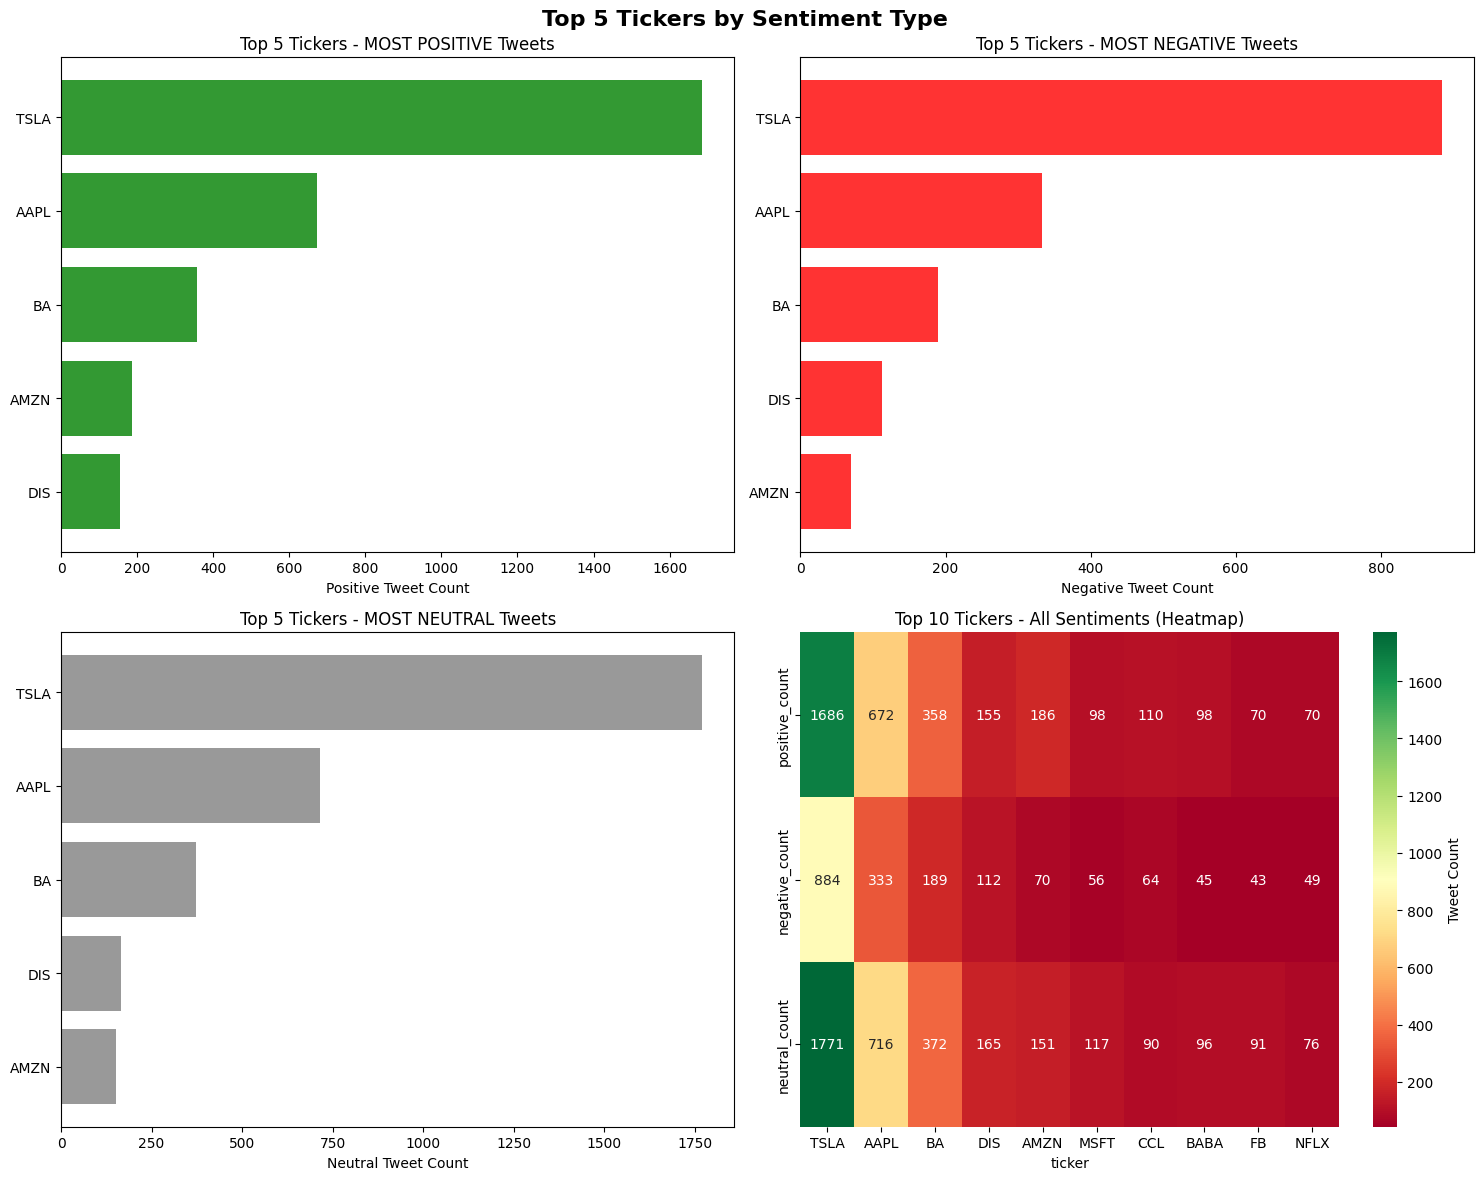

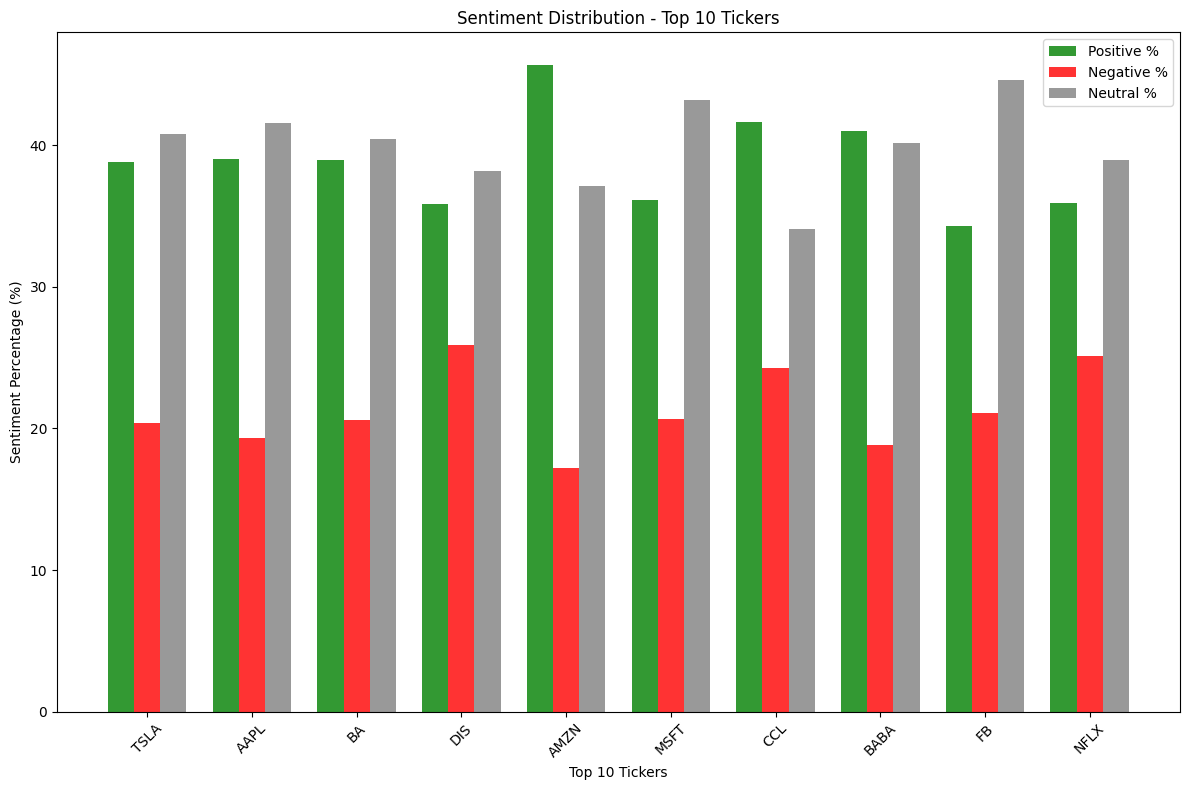


=== TOP 5 POSITIVE TICKERS ===
ticker  positive_count  avg_compound
  TSLA            1686      0.099475
  AAPL             672      0.105604
    BA             358      0.101437
  AMZN             186      0.151804
   DIS             155      0.068029

=== TOP 5 NEGATIVE TICKERS ===
ticker  negative_count  avg_compound
  TSLA             884      0.099475
  AAPL             333      0.105604
    BA             189      0.101437
   DIS             112      0.068029
  AMZN              70      0.151804

=== TOP 5 NEUTRAL TICKERS ===
ticker  neutral_count  avg_compound
  TSLA           1771      0.099475
  AAPL            716      0.105604
    BA            372      0.101437
   DIS            165      0.068029
  AMZN            151      0.151804

 PLOTS SAVED:
1. sentiment_top5_tickers.png (4 subplots)
2. sentiment_ratio_top10.png (stacked bars)


In [135]:
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

spark = SparkSession.builder.appName("SentimentPlots").getOrCreate()

# Load sentiment data
df_sentiment = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("file:///home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_sentiment_analysis/*.csv")

print(f"Loaded {df_sentiment.count()} sentiment rows")

# -----------------------------
# 1) AGGREGATE SENTIMENT BY TICKER
# -----------------------------
df_ticker_sentiment = df_sentiment.filter(F.col("clean_text").isNotNull()).groupBy("ticker").agg(
    F.count("*").alias("total_tweets"),
    F.avg("sentiment_compound").alias("avg_compound"),
    F.sum(F.when(F.col("sentiment_label") == "positive", 1).otherwise(0)).alias("positive_count"),
    F.sum(F.when(F.col("sentiment_label") == "negative", 1).otherwise(0)).alias("negative_count"),
    F.sum(F.when(F.col("sentiment_label") == "neutral", 1).otherwise(0)).alias("neutral_count")
).orderBy(F.desc("total_tweets"))

print("\n=== TICKER SENTIMENT SUMMARY ===")
df_ticker_sentiment.show(20)

# -----------------------------
# 2) CONVERT TO PANDAS FOR PLOTTING
# -----------------------------
df_plot = df_ticker_sentiment.toPandas()

# Top 5 by each sentiment type
top_positive = df_plot.nlargest(5, 'positive_count')
top_negative = df_plot.nlargest(5, 'negative_count') 
top_neutral = df_plot.nlargest(5, 'neutral_count')

print(f"\nTop 5 Positive: {len(top_positive)} tickers")
print(f"Top 5 Negative: {len(top_negative)} tickers") 
print(f"Top 5 Neutral: {len(top_neutral)} tickers")

# -----------------------------
# 3) CREATE VISUALIZATIONS
# -----------------------------
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Top 5 Tickers by Sentiment Type', fontsize=16, fontweight='bold')

# 1. TOP 5 POSITIVE
axes[0,0].barh(top_positive['ticker'], top_positive['positive_count'], color='green', alpha=0.8)
axes[0,0].set_title('Top 5 Tickers - MOST POSITIVE Tweets')
axes[0,0].set_xlabel('Positive Tweet Count')
axes[0,0].invert_yaxis()

# 2. TOP 5 NEGATIVE  
axes[0,1].barh(top_negative['ticker'], top_negative['negative_count'], color='red', alpha=0.8)
axes[0,1].set_title('Top 5 Tickers - MOST NEGATIVE Tweets')
axes[0,1].set_xlabel('Negative Tweet Count')
axes[0,1].invert_yaxis()

# 3. TOP 5 NEUTRAL
axes[1,0].barh(top_neutral['ticker'], top_neutral['neutral_count'], color='gray', alpha=0.8)
axes[1,0].set_title('Top 5 Tickers - MOST NEUTRAL Tweets')
axes[1,0].set_xlabel('Neutral Tweet Count')
axes[1,0].invert_yaxis()

# 4. COMBINED HEATMAP (All sentiments)
pivot_data = df_plot.head(10)[['ticker', 'positive_count', 'negative_count', 'neutral_count']]
pivot_table = pivot_data.set_index('ticker').T
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1,1], cbar_kws={'label': 'Tweet Count'})
axes[1,1].set_title('Top 10 Tickers - All Sentiments (Heatmap)')

plt.tight_layout()
plt.savefig('/home/hduser/Downloads/stock-tweet-and-price/stockprice/sentiment_top5_tickers.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 5) ADVANCED PLOT: Sentiment Ratio by Ticker
# -----------------------------
plt.figure(figsize=(12, 8))
colors = ['green', 'red', 'gray']
labels = ['Positive %', 'Negative %', 'Neutral %']

# Top 10 tickers
top_10 = df_plot.head(10)
x = np.arange(len(top_10))
width = 0.25

for i, sentiment in enumerate(['positive_count', 'negative_count', 'neutral_count']):
    plt.bar(x + i*width, top_10[sentiment]/top_10['total_tweets']*100, 
            width, label=labels[i], color=colors[i], alpha=0.8)

plt.xlabel('Top 10 Tickers')
plt.ylabel('Sentiment Percentage (%)')
plt.title('Sentiment Distribution - Top 10 Tickers')
plt.xticks(x + width, top_10['ticker'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('/home/hduser/Downloads/stock-tweet-and-price/stockprice/sentiment_ratio_top10.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 6) PRINT TOP 5 RESULTS
# -----------------------------
print("\n=== TOP 5 POSITIVE TICKERS ===")
print(top_positive[['ticker', 'positive_count', 'avg_compound']].to_string(index=False))

print("\n=== TOP 5 NEGATIVE TICKERS ===")
print(top_negative[['ticker', 'negative_count', 'avg_compound']].to_string(index=False))

print("\n=== TOP 5 NEUTRAL TICKERS ===")
print(top_neutral[['ticker', 'neutral_count', 'avg_compound']].to_string(index=False))

print("\n PLOTS SAVED:")
print("1. sentiment_top5_tickers.png (4 subplots)")
print("2. sentiment_ratio_top10.png (stacked bars)")

spark.stop()


Training: 8006 | Test: 2002

=== TRAINING MNB MODEL ===
Accuracy Score: 0.8191808191808192

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.40      0.57       316
     Neutral       0.78      1.00      0.88      1211
    Positive       0.92      0.64      0.76       475

    accuracy                           0.82      2002
   macro avg       0.89      0.68      0.73      2002
weighted avg       0.85      0.82      0.80      2002


=== CONFUSION MATRIX ===
Classes: [0 1 2]


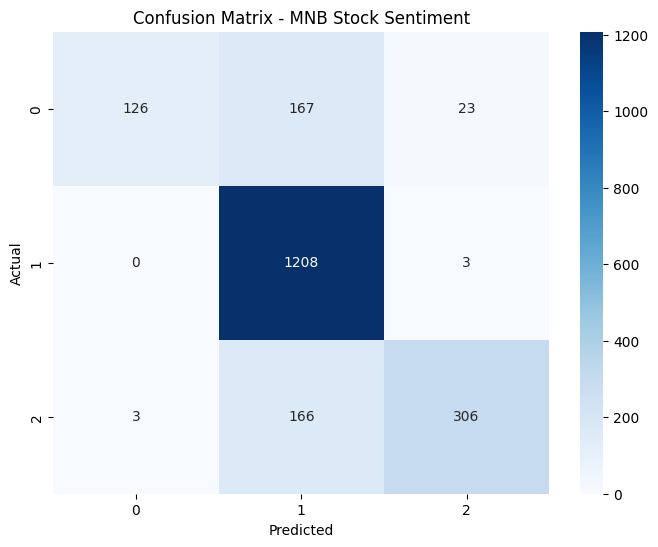

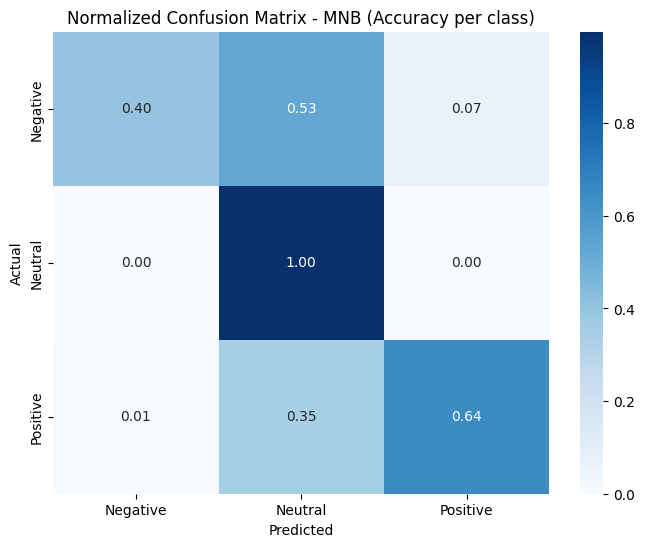


=== FULL DATASET PREDICTIONS ===
Full dataset distribution:
mnb_label
neutral     7191
positive    1869
negative     948
Name: count, dtype: int64

 FULL RESULTS SAVED: /home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_mnb_full_results.csv

=== PRICE BY MNB SENTIMENT ===
             mean  count
mnb_label               
negative   101.02    270
neutral    116.49   1989
positive   112.44    499

 MNB + CONFUSION MATRIX COMPLETE!
Accuracy: 0.8192
Confusion Matrix: confusion_matrix_mnb.png
Normalized: confusion_matrix_normalized.png


In [113]:
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
spark = SparkSession.builder.appName("MNB_ConfusionMatrix").getOrCreate()
df_data = spark.read.option("header", "true").option("inferSchema", "true") \
    .csv("file:///home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_price_tweet_full_outer.csv")

df_pd = df_data.select("ticker", "Date_std", "Close", "clean_text") \
    .filter(F.col("clean_text").isNotNull()).toPandas()

# -----------------------------
# 1) RULE-BASED LABELING + TRAIN/TEST SPLIT
# -----------------------------
df_pd['label'] = np.where(
    df_pd['clean_text'].str.contains('bull|moon|buy|rocket|calls|long|pump', case=False, na=False), 2,
    np.where(
        df_pd['clean_text'].str.contains('bear|dump|crash|sell|puts|short|fade', case=False, na=False), 0,
        1
    )
)

X = df_pd['clean_text']
Y = df_pd['label']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"Training: {len(X_train)} | Test: {len(X_test)}")

# -----------------------------
# 2) TF-IDF + MNB CODE
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

print("\n=== TRAINING MNB MODEL ===")
MNB = MultinomialNB()
MNB.fit(X_train_vectors, Y_train)

predicted = MNB.predict(X_test_vectors)
accuracy_score_result = metrics.accuracy_score(Y_test, predicted)
print("Accuracy Score:", accuracy_score_result)

print("\nClassification Report:")
print(classification_report(Y_test, predicted, target_names=['Negative', 'Neutral', 'Positive']))

# -----------------------------
# 3) CONFUSION MATRIX CODE
# -----------------------------
print("\n=== CONFUSION MATRIX ===")
from sklearn.metrics import confusion_matrix

# Get class labels
classes = np.unique(Y_test)
print("Classes:", classes)

# Generate and plot EXACT CODE
cm = confusion_matrix(Y_test, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - MNB Stock Sentiment')
plt.savefig('/home/hduser/Downloads/stock-tweet-and-price/stockprice/confusion_matrix_mnb.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 4) NORMALIZED CONFUSION MATRIX
# -----------------------------
cm_normalized = confusion_matrix(Y_test, predicted, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix - MNB (Accuracy per class)')
plt.savefig('/home/hduser/Downloads/stock-tweet-and-price/stockprice/confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 5) FULL DATASET PREDICTIONS + SAVE
# -----------------------------
print("\n=== FULL DATASET PREDICTIONS ===")
X_full_vectors = vectorizer.transform(df_pd['clean_text'])
df_pd['mnb_prediction'] = MNB.predict(X_full_vectors)
df_pd['mnb_proba'] = np.max(MNB.predict_proba(X_full_vectors), axis=1)

label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_pd['mnb_label'] = df_pd['mnb_prediction'].map(label_names)

print("Full dataset distribution:")
print(df_pd['mnb_label'].value_counts())

# Save results
output_csv = "/home/hduser/Downloads/stock-tweet-and-price/stockprice/stock_mnb_full_results.csv"
df_pd.to_csv(output_csv, index=False)
print(f"\n FULL RESULTS SAVED: {output_csv}")

# -----------------------------
# 6) PRICE ANALYSIS
# -----------------------------
print("\n=== PRICE BY MNB SENTIMENT ===")
price_analysis = df_pd.dropna(subset=['Close']).groupby('mnb_label')['Close'].agg(['mean', 'count']).round(2)
print(price_analysis)

spark.stop()
print("\n MNB + CONFUSION MATRIX COMPLETE!")
print(f"Accuracy: {accuracy_score_result:.4f}")
print("Confusion Matrix: confusion_matrix_mnb.png")
print("Normalized: confusion_matrix_normalized.png")


### Real-time analytics

In [ ]:
import os
import findspark

# 1.Spark Installation
os.environ["SPARK_HOME"] = "/usr/local/spark"

# 2. Configure pyspark in Pyspark_venv
os.environ["PYSPARK_PYTHON"] = "/home/hduser/pyspark_venv/bin/python3"

# 3. Initialize PySpark using findspark
findspark.init()

print("Spark environment configured for the current kernel.")

from pyspark.sql import SparkSession

# Define memory limits
SPARK_DRIVER_MEMORY = "16g" 
SPARK_MAX_RESULT_SIZE = "8g" 

try:
    SparkSession.builder.getOrCreate().stop() 
except:
    pass

spark = (
    SparkSession.builder
    .appName("RedditLiveAnalytics")
    .config("spark.driver.memory", SPARK_DRIVER_MEMORY)
    .config("spark.driver.maxResultSize", SPARK_MAX_RESULT_SIZE)
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") 
    .getOrCreate()
)

print(f"PySpark Session successfully launched in the 'PySpark Venv' kernel.")

In [119]:
import praw
import json
from datetime import datetime

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="VOkajS109Egv7Fd73kxAjg",                              
    client_secret="xI8t9brfX5yaHpY-9DlROAM0Tjgn8Q",                  
    user_agent="BDSPDataCollector by happ-Preference-3430"
           # Custom user agent with your Reddit username
)

# Fetch latest posts from the subreddit and store in a local file
def fetch_and_store_reddit_data(subreddit_name="stocknews"):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    for post in subreddit.new(limit=10):  # Limit to 10 posts
        post_data = {
            "id": post.id,
            "title": post.title,
            "author": post.author.name if post.author else None,
            "created_utc": post.created_utc,
            "selftext": post.selftext,
            "score": post.score,
            "comments": post.num_comments
        }
        posts.append(post_data)
    
    # Convert posts to JSON
    posts_json = json.dumps(posts, indent=4)
    
    # Define a fixed filename for overwriting
    local_filename = "/home/hduser/Desktop/stocks_posts.json"
    
    # Write to local file system (this will overwrite the file each time)
    with open(local_filename, 'w') as local_file:
        local_file.write(posts_json)
    
    print(f"Data written to local file: {local_filename}")

# Call the function to fetch and store Reddit data
fetch_and_store_reddit_data("stocknews")

Data written to local file: /home/hduser/Desktop/stocks_posts.json


In [120]:
import praw
import json
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, col, desc
import os

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="VOkajS109Egv7Fd73kxAjg",                              # Find from your Reddit account
    client_secret="xI8t9brfX5yaHpY-9DlROAM0Tjgn8Q",                  # Create username and find your own client secret
    user_agent="BDSPDataCollector by happ-Preference-3430"

)

# Fetch Reddit posts
def fetch_and_store_reddit_data(subreddit_name="stocknews"):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    for post in subreddit.new(limit=10):  # Limit to 10 posts
        post_data = {
            "id": post.id,
            "title": post.title,
            "author": post.author.name if post.author else None,
            "created_utc": post.created_utc,
            "selftext": post.selftext,
            "score": post.score,
            "comments": post.num_comments
        }
        posts.append(post_data)

    # Set a consistent filename for the posts (appending to same file)
    local_filename = f"/home/hduser/Desktop/{subreddit_name}_posts.json"

    # Append to the same file
    with open(local_filename, 'a') as local_file:
        for post in posts:
            json.dump(post, local_file)
            local_file.write("\n")  # Newline delimiter between posts

    print(f"Data written to local file: {local_filename}")

# Initialize Spark session
spark = SparkSession.builder \
    .appName("RedditWordFrequency") \
    .master("local[*]") \
    .getOrCreate()

# Define file path (using the same consistent filename)
file_path = "file:///home/hduser/Desktop/stocknews_posts.json"  # Replace with your actual path if needed

# Step 1: Load the Reddit JSON data
reddit_df = spark.read.option("multiLine", "true").json(file_path)

# Step 2: Extract title and selftext, combine them for word analysis
reddit_text_df = reddit_df.selectExpr("concat(coalesce(title, ''), ' ', coalesce(selftext, '')) as text")

# Step 3: Split the text into individual words
words_df = reddit_text_df.select(
    explode(
        split(lower(col("text")), "\\W+")
    ).alias("word")
)

# Step 4: Remove empty words (optional but cleaner)
words_df = words_df.filter(col("word") != "")

# Step 5: Count the frequency of each word
word_count_df = words_df.groupBy("word").count().orderBy(desc("count"))

# Show top 20 words
word_count_df.show(20, truncate=False)

# Step 6: Find the word(s) that appeared maximum number of times
max_count = word_count_df.agg({"count": "max"}).collect()[0][0]

print(f"\nWord(s) with maximum occurrence ({max_count} times):")
word_count_df.filter(col("count") == max_count).show(truncate=False)

# Stop Spark session
spark.stop()


fetch_and_store_reddit_data("stocknews") 

25/12/06 22:21:17 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+----------+-----+
|word      |count|
+----------+-----+
|q125      |1    |
|after     |1    |
|on        |1    |
|end       |1    |
|hits      |1    |
|500b      |1    |
|wmt       |1    |
|cap       |1    |
|week      |1    |
|market    |1    |
|walmart   |1    |
|nyse      |1    |
|of        |1    |
|rally     |1    |
|results   |1    |
|impressive|1    |
+----------+-----+


Word(s) with maximum occurrence (1 times):
+----------+-----+
|word      |count|
+----------+-----+
|q125      |1    |
|after     |1    |
|on        |1    |
|end       |1    |
|hits      |1    |
|500b      |1    |
|wmt       |1    |
|cap       |1    |
|week      |1    |
|market    |1    |
|walmart   |1    |
|nyse      |1    |
|of        |1    |
|rally     |1    |
|results   |1    |
|impressive|1    |
+----------+-----+

Data written to local file: /home/hduser/Desktop/stocknews_posts.json


### Collect the data for 30 seconds on Reddit

In [121]:
import praw
import json
import time
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, col, desc

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="VOkajS109Egv7Fd73kxAjg",                              # Find from your Reddit account
    client_secret="xI8t9brfX5yaHpY-9DlROAM0Tjgn8Q",                  # Create username and find your own client secret
    user_agent="BDSPDataCollector by happ-Preference-3430"

)

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("RedditLiveAnalytics") \
    .master("local[*]") \
    .getOrCreate()

# Function to fetch Reddit posts for 30 seconds
def fetch_reddit_posts(duration_sec=30, subreddit_name="stocknews"):
    print(f"\nFetching posts from r/{subreddit_name} for {duration_sec} seconds...")
    posts = []
    start_time = time.time()
    while (time.time() - start_time) < duration_sec:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            for post in subreddit.new(limit=5):  # Fetch latest 5 posts quickly
                post_data = {
                    "id": post.id,
                    "title": post.title,
                    "selftext": post.selftext if post.selftext else ""
                }
                posts.append(post_data)
            time.sleep(5)  # Sleep for 5 seconds to avoid hitting API too fast
        except Exception as e:
            print(f"Error fetching posts: {e}")
            time.sleep(5)
    return posts

# Function to analyze posts with PySpark
def analyze_posts(posts):
    if not posts:
        print("No posts to analyze.")
        return
    # Create a temporary JSON file
    temp_filename = f"/tmp/reddit_temp_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(temp_filename, 'w') as f:
        for post in posts:
            json.dump(post, f)
            f.write("\n")  # Newline-delimited JSON (NDJSON)
    
    # Read with Spark
    reddit_df = spark.read.json(f"file://{temp_filename}")
    
    reddit_text_df = reddit_df.selectExpr("concat(coalesce(title, ''), ' ', coalesce(selftext, '')) as text")
    
    words_df = reddit_text_df.select(
        explode(
            split(lower(col("text")), "\\W+")
        ).alias("word")
    )
    
    words_df = words_df.filter(col("word") != "")
    
    word_count_df = words_df.groupBy("word").count().orderBy(desc("count"))
    
    print("\nTop 20 Words:")
    word_count_df.show(20, truncate=False)
    
    max_count = word_count_df.agg({"count": "max"}).collect()[0][0]
    print(f"\nWord(s) with maximum occurrence ({max_count} times):")
    word_count_df.filter(col("count") == max_count).show(truncate=False)

# Main loop
while True:
    posts = fetch_reddit_posts(duration_sec=30)
    analyze_posts(posts)
    
    choice = input("\nDo you want to fetch and analyze again? (yes/no): ").strip().lower()
    if choice != 'yes':
        print("Exiting program. Thank you for using this Pyspark Application for real time analytics")
        break

# Stop Spark session
spark.stop()


Fetching posts from r/stocknews for 30 seconds...

Top 20 Words:
+---------+-----+
|word     |count|
+---------+-----+
|on       |30   |
|nyse     |30   |
|after    |18   |
|results  |18   |
|positive |12   |
|revenue  |12   |
|guidance |12   |
|q1       |12   |
|wednesday|12   |
|week     |12   |
|surges   |12   |
|2024     |12   |
|industry |6    |
|bleak    |6    |
|11       |6    |
|plunges  |6    |
|shop     |6    |
|news     |6    |
|beats    |6    |
|race     |6    |
+---------+-----+
only showing top 20 rows


Word(s) with maximum occurrence (30 times):
+----+-----+
|word|count|
+----+-----+
|on  |30   |
|nyse|30   |
+----+-----+


Do you want to fetch and analyze again? (yes/no): no
Exiting program. Thank you for using this Pyspark Application for real time analytics


### Store the Reddit posts data in a file along with analytics

In [123]:
import praw
import json
import time
import os
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, col, desc

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="VOkajS109Egv7Fd73kxAjg",                              # Find from your Reddit account
    client_secret="xI8t9brfX5yaHpY-9DlROAM0Tjgn8Q",                  # Create username and find your own client secret
    user_agent="BDSPDataCollector by happ-Preference-3430"

)

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("RedditLiveAnalytics") \
    .master("local[*]") \
    .getOrCreate()

# Define paths and settings
fixed_filename = "/tmp/reddit_collected_posts.json"
temp_batch_file = "/tmp/reddit_temp_batch.json"

# Before starting, delete the old files if they exist
if os.path.exists(fixed_filename):
    os.remove(fixed_filename)
    print(f"Removed old collected file: {fixed_filename}")
if os.path.exists(temp_batch_file):
    os.remove(temp_batch_file)
    print(f"Removed old temp file: {temp_batch_file}")

# --- 3. Function Definitions ---

def fetch_reddit_posts(duration_sec=30, subreddit_name="stocknews"):
    """Fetches the newest posts from a subreddit for a set duration."""
    print(f"\n Fetching posts from r/{subreddit_name} for {duration_sec} seconds...")
    posts = []
    seen_ids = set()
    start_time = time.time()
    
    # We use a while loop to fetch multiple batches over the duration
    while (time.time() - start_time) < duration_sec:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            # Iterate through the latest posts
            for post in subreddit.new(limit=5):
                if post.id not in seen_ids:
                    post_data = {
                        "id": post.id,
                        "title": post.title,
                        "selftext": post.selftext if post.selftext else "",
                        "timestamp": int(time.time()) # Add a timestamp for tracking
                    }
                    posts.append(post_data)
                    seen_ids.add(post.id)
            
            # Sleep to respect Reddit API rate limits and fetch new content
            time.sleep(5) 
            
        except Exception as e:
            print(f"Error fetching posts: {e}. Retrying in 5 seconds.")
            time.sleep(5)
            
    print(f"Finished fetching. Collected {len(posts)} new posts.")
    return posts

def append_posts_to_file(posts, filename):
    """Appends posts to the fixed JSON file in NDJSON format."""
    if not posts:
        return

    # Use 'a' mode for append
    with open(filename, 'a', encoding='utf-8') as f:
        for post in posts:
            # json.dump writes the JSON object
            json.dump(post, f) 
            # f.write("\n") ensures the file is Newline-Delimited JSON (NDJSON), 
            # which Spark can easily read incrementally.
            f.write("\n")

def analyze_posts(spark_session, posts, temp_path):
    """Analyzes the current batch of posts using Spark."""
    if not posts:
        print("No posts to analyze in this batch.")
        return
        
    print(f"\n Starting Spark analysis on {len(posts)} posts...")
    
    # 1. Save the current batch to a temporary file (Spark needs a file path)
    try:
        with open(temp_path, 'w', encoding='utf-8') as f:
            for post in posts:
                json.dump(post, f)
                f.write("\n")
    except Exception as e:
        print(f"Error writing temporary file: {e}")
        return
        
    # 2. Read the batch into a Spark DataFrame
    # Use "file://" prefix for local file paths in Spark
    reddit_df = spark_session.read.json(f"file://{temp_path}")
    
    # 3. Text Preparation
    reddit_text_df = reddit_df.selectExpr("concat(coalesce(title, ''), ' ', coalesce(selftext, '')) as text")
    
    # 4. Tokenization (Split text into words)
    words_df = reddit_text_df.select(
        explode(
            split(lower(col("text")), "\\W+") # Split by non-word characters and convert to lowercase
        ).alias("word")
    )
    
    # 5. Filtering (Remove empty strings from splitting)
    words_df = words_df.filter(col("word") != "")
    
    # 6. Count and Sort
    word_count_df = words_df.groupBy("word").count().orderBy(desc("count"))
    
    # 7. Display Results
    print("\n Top 20 Words in this batch:")
    word_count_df.show(20, truncate=False)
    
    # Optional: Find word(s) with maximum occurrence
    try:
        max_count_row = word_count_df.agg({"count": "max"}).collect()
        if max_count_row:
            max_count = max_count_row[0][0]
            if max_count is not None:
                print(f"\n Word(s) with maximum occurrence in this batch ({max_count} times):")
                word_count_df.filter(col("count") == max_count).show(truncate=False)
            else:
                print("No words found for analysis.")
    except Exception:
        # Handle case where DataFrame is empty after filtering
        print("No words found for analysis.")

# --- 4. Main Execution Loop (THE MISSING PIECE) ---

# --- Define loop parameters ---
TOTAL_RUN_DURATION_SEC = 120 # Run for 2 minutes (120 seconds) for testing
BATCH_FETCH_DURATION_SEC = 30 # Fetch data every 30 seconds

print(f"\n Starting Reddit live analytics loop for {TOTAL_RUN_DURATION_SEC} seconds...")
print(f"Data will be saved to: {fixed_filename}")
print("-" * 50)

loop_start_time = time.time()
iteration = 0

# Loop runs until the total duration is reached
while (time.time() - loop_start_time) < TOTAL_RUN_DURATION_SEC:
    iteration += 1
    print(f"\n--- Batch Iteration {iteration} ---")
    
    # 1. FETCH posts
    current_posts = fetch_reddit_posts(duration_sec=BATCH_FETCH_DURATION_SEC)
    
    # 2. SAVE posts (Fixing your original issue)
    if current_posts:
        append_posts_to_file(current_posts, fixed_filename)
        print(f"Appended {len(current_posts)} posts to {fixed_filename}")
        
    # 3. ANALYZE posts
    analyze_posts(spark, current_posts, temp_batch_file)
    
    
print("-" * 50)
print("Loop finished.")
print(f"Total time elapsed: {int(time.time() - loop_start_time)} seconds.")
print(f"Final collected data is saved in: **{fixed_filename}**")

# Stop the Spark session
spark.stop()


 Starting Reddit live analytics loop for 120 seconds...
Data will be saved to: /tmp/reddit_collected_posts.json
--------------------------------------------------

--- Batch Iteration 1 ---

 Fetching posts from r/stocknews for 30 seconds...
Finished fetching. Collected 5 new posts.
Appended 5 posts to /tmp/reddit_collected_posts.json

 Starting Spark analysis on 5 posts...

 Top 20 Words in this batch:
+---------+-----+
|word     |count|
+---------+-----+
|on       |5    |
|nyse     |5    |
|after    |3    |
|results  |3    |
|positive |2    |
|revenue  |2    |
|guidance |2    |
|q1       |2    |
|wednesday|2    |
|week     |2    |
|surges   |2    |
|2024     |2    |
|industry |1    |
|bleak    |1    |
|11       |1    |
|plunges  |1    |
|shop     |1    |
|news     |1    |
|beats    |1    |
|race     |1    |
+---------+-----+
only showing top 20 rows


 Word(s) with maximum occurrence in this batch (5 times):
+----+-----+
|word|count|
+----+-----+
|on  |5    |
|nyse|5    |
+----+----

**Rationale:**

    - Batch streaming analysis using Spark enables to retrieve real-time analytics from Reddit. 
    
PRAW collects stocknews from Reddit and the information are consumed on Spark. Data stored in batched are saved in the newline Delimed JSON format

In [124]:
INPUT_FILE = "/tmp/reddit_collected_posts.json"
STREAM_DIR = "/tmp/reddit_stream_folder"


In [125]:
import os, shutil

os.makedirs(STREAM_DIR, exist_ok=True)
shutil.copy(INPUT_FILE, os.path.join(STREAM_DIR, "reddit_collected_posts.json"))


'/tmp/reddit_stream_folder/reddit_collected_posts.json'

### Structured Streaming and analytics on Spark

In [126]:
import os
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StringType

INPUT_FILE = "/tmp/reddit_collected_posts.json"
STREAM_DIR = "/tmp/reddit_stream_folder"

# Ensure the streaming folder exists and copy the file
os.makedirs(STREAM_DIR, exist_ok=True)
shutil.copy(INPUT_FILE, os.path.join(STREAM_DIR, "reddit_collected_posts.json"))

# Define schema
schema = StructType() \
    .add("id", StringType()) \
    .add("title", StringType()) \
    .add("selftext", StringType()) \
    .add("timestamp", StringType())

# Initialize Spark
spark = SparkSession.builder \
    .appName("RedditFileStreaming") \
    .master("local[*]") \
    .getOrCreate()

# Read streaming data
stream_df = spark.readStream \
    .schema(schema) \
    .option("maxFilesPerTrigger", 1) \
    .json(f"file://{STREAM_DIR}")

# Use foreachBatch to stop after processing all files
def process_batch(batch_df, batch_id):
    if batch_df.count() > 0:
        batch_df.show(truncate=False)
    # Stop the query after first batch
    query.stop()

query = stream_df.writeStream \
    .outputMode("append") \
    .foreachBatch(process_batch) \
    .start()

query.awaitTermination()


25/12/06 22:32:52 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-b605323e-2bbe-4f73-8fea-cfc279cf13b2. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/12/06 22:32:52 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


+-------+------------------------------------------------------------------------------------------------------------+--------+----------+
|id     |title                                                                                                       |selftext|timestamp |
+-------+------------------------------------------------------------------------------------------------------------+--------+----------+
|1cvexym|Walmart (NYSE: $WMT) Hits $500B+ Market Cap After End of Week Rally on Impressive Q125 Results              |        |1765059833|
|1ctxjt8|Super Micro Computer (NYSE: $SMCI) Surges 12% This Week Amid Positive AI Industry News\n                    |        |1765059833|
|1coi7iq|Shopify (NYSE: #SHOP) Reports Q1 2024 Revenue Surge – Plunges 19%+ on Wednesday on Bleak Guidance           |        |1765059833|
|1cnmobp|Reddit (NYSE: $RDDT) Surges 11% on Wednesday After Stellar Debut Quarterly Results – Revenue Beats Estimates|        |1765059833|
|1cmw59r|Ferrari (NYSE: #RA

In [2]:
import os
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StringType
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType as PyStringType
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# --- Setup directories ---
INPUT_FILE = "/home/hduser/Desktop/stocknews_posts.json"
STREAM_DIR = "/home/hduser/Desktop/stocknews_stream"
OUTPUT_DIR = "/home/hduser/Desktop/stocknews_sentiment_output"

os.makedirs(STREAM_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Copy JSON file to streaming folder
shutil.copy(INPUT_FILE, os.path.join(STREAM_DIR, "stocknews_posts.json"))

# --- Define schema ---
schema = StructType() \
    .add("id", StringType()) \
    .add("title", StringType()) \
    .add("selftext", StringType()) \
    .add("timestamp", StringType())

# --- Initialize Spark ---
spark = SparkSession.builder \
    .appName("StockNewsSentimentStreaming") \
    .master("local[*]") \
    .getOrCreate()

# --- Read streaming JSON ---
stream_df = spark.readStream \
    .schema(schema) \
    .option("maxFilesPerTrigger", 1) \
    .json(f"file://{STREAM_DIR}")

# --- VADER Sentiment UDF ---
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text:
        return "neutral"
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

sentiment_udf = udf(get_sentiment, PyStringType())

# --- Apply sentiment ---
processed_df = stream_df.withColumn(
    "text",
    stream_df["title"]
).withColumn(
    "sentiment",
    sentiment_udf("text")
)

# --- Process each batch ---
def process_batch(batch_df, batch_id):
    if batch_df.count() > 0:
        print(f"Processing batch {batch_id} with VADER sentiment:")
        batch_df.show(truncate=False)
        # Write to CSV locally
        output_path = f"file://{OUTPUT_DIR}/batch_{batch_id}"
        batch_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path)
    # Stop after first batch for testing
    query.stop()

# --- Start streaming query ---
query = processed_df.writeStream \
    .outputMode("append") \
    .foreachBatch(process_batch) \
    .start()

query.awaitTermination()

25/12/12 20:39:33 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
25/12/12 20:39:34 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-4567b662-8dac-471d-98bf-1126bec5eaa1. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
25/12/12 20:39:34 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Processing batch 0 with VADER sentiment:
+-------+---------------------------------------------------------------------------------------------------------------+--------+---------+---------------------------------------------------------------------------------------------------------------+---------+
|id     |title                                                                                                          |selftext|timestamp|text                                                                                                           |sentiment|
+-------+---------------------------------------------------------------------------------------------------------------+--------+---------+---------------------------------------------------------------------------------------------------------------+---------+
|1cvexym|Walmart (NYSE: $WMT) Hits $500B+ Market Cap After End of Week Rally on Impressive Q125 Results                 |        |NULL     |Walmart (NYSE: $WMT) Hits $500

25/12/12 20:39:41 WARN DAGScheduler: Broadcasting large task binary with size 1060.8 KiB


* Dr. Muhammad Iqbal CCT, College Dublin